In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style professionnel
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Chargement
df = pd.read_csv("Data/ai4i2020.csv")

print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📋 Colonnes : {list(df.columns)}")

✅ Dataset chargé : 10000 lignes × 14 colonnes

📋 Colonnes : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [2]:
# ============================================================
# CELLULE 1 — Imports et configuration
# ============================================================
# On importe toutes les librairies nécessaires
# pandas  = manipulation de données (comme Excel en Python)
# numpy   = calculs mathématiques
# matplotlib / seaborn / plotly = visualisations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style professionnel pour tous les graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


In [3]:
# ============================================================
# CELLULE 2 — Chargement des données
# ============================================================
# On charge le dataset brut (Bronze)
# C'est exactement ce qu'on a uploadé dans ADLS en J3

df = pd.read_csv("Data/ai4i2020.csv")

print("=" * 55)
print("     DATASET OCP — INFORMATIONS GÉNÉRALES")
print("=" * 55)
print(f"📊 Lignes     : {df.shape[0]:,}")
print(f"📋 Colonnes   : {df.shape[1]}")
print(f"💾 Mémoire    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 55)
print("\n📋 Aperçu des premières lignes :")
df.head()

     DATASET OCP — INFORMATIONS GÉNÉRALES
📊 Lignes     : 10,000
📋 Colonnes   : 14
💾 Mémoire    : 1963.0 KB

📋 Aperçu des premières lignes :


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# ============================================================
# CELLULE 3 — Structure et types des colonnes
# ============================================================
# dtype = type de données de chaque colonne
# object = texte, int64 = entier, float64 = décimal

print("📋 STRUCTURE DES COLONNES :")
print("-" * 45)
for col in df.columns:
    dtype   = df[col].dtype
    nunique = df[col].nunique()
    sample  = df[col].iloc[0]
    print(f"  {col:<35} {str(dtype):<10} ({nunique} valeurs uniques)")

print("\n\n📊 STATISTIQUES DESCRIPTIVES :")
df.describe().round(2)

📋 STRUCTURE DES COLONNES :
---------------------------------------------
  UDI                                 int64      (10000 valeurs uniques)
  Product ID                          str        (10000 valeurs uniques)
  Type                                str        (3 valeurs uniques)
  Air temperature [K]                 float64    (93 valeurs uniques)
  Process temperature [K]             float64    (82 valeurs uniques)
  Rotational speed [rpm]              int64      (941 valeurs uniques)
  Torque [Nm]                         float64    (577 valeurs uniques)
  Tool wear [min]                     int64      (246 valeurs uniques)
  Machine failure                     int64      (2 valeurs uniques)
  TWF                                 int64      (2 valeurs uniques)
  HDF                                 int64      (2 valeurs uniques)
  PWF                                 int64      (2 valeurs uniques)
  OSF                                 int64      (2 valeurs uniques)
  RNF         

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


📊 RAPPORT VALEURS MANQUANTES :
                Colonne  Valeurs_nulles  Pourcentage_%
                    UDI               0            0.0
             Product ID               0            0.0
                   Type               0            0.0
    Air temperature [K]               0            0.0
Process temperature [K]               0            0.0
 Rotational speed [rpm]               0            0.0
            Torque [Nm]               0            0.0
        Tool wear [min]               0            0.0
        Machine failure               0            0.0
                    TWF               0            0.0
                    HDF               0            0.0
                    PWF               0            0.0
                    OSF               0            0.0
                    RNF               0            0.0


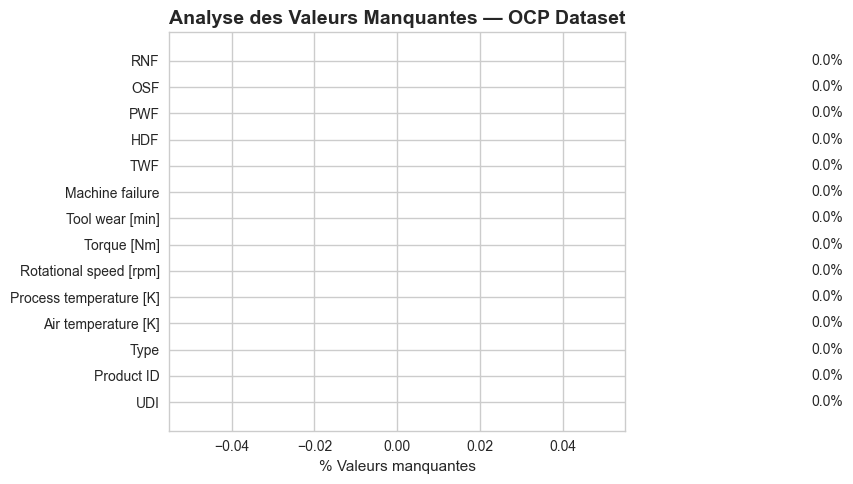


✅ Aucune valeur manquante — Dataset complet !


In [5]:
    # ============================================================
# CELLULE 4 — Analyse des valeurs manquantes
# ============================================================
# Une valeur manquante = trou dans les données
# Le ML ne peut pas traiter les NaN directement
# → il faut savoir combien il y en a et où

missing = pd.DataFrame({
    'Colonne'        : df.columns,
    'Valeurs_nulles' : df.isnull().sum().values,
    'Pourcentage_%'  : (df.isnull().sum() / len(df) * 100).round(2).values
}).sort_values('Valeurs_nulles', ascending=False)

print("📊 RAPPORT VALEURS MANQUANTES :")
print(missing.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' 
          for v in missing['Valeurs_nulles']]
bars = ax.barh(missing['Colonne'], 
               missing['Pourcentage_%'],
               color=colors)
ax.set_xlabel('% Valeurs manquantes')
ax.set_title('Analyse des Valeurs Manquantes — OCP Dataset', 
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, missing['Pourcentage_%']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

if missing['Valeurs_nulles'].sum() == 0:
    print("\n✅ Aucune valeur manquante — Dataset complet !")
else:
    print(f"\n⚠️  {missing['Valeurs_nulles'].sum()} valeurs manquantes détectées")

   DISTRIBUTION DE LA VARIABLE CIBLE
  Sain  (0) : 9,661 lignes → 96.6%
  Panne (1) : 339 lignes → 3.4%
  Ratio     : 1 panne pour 28 mesures saines


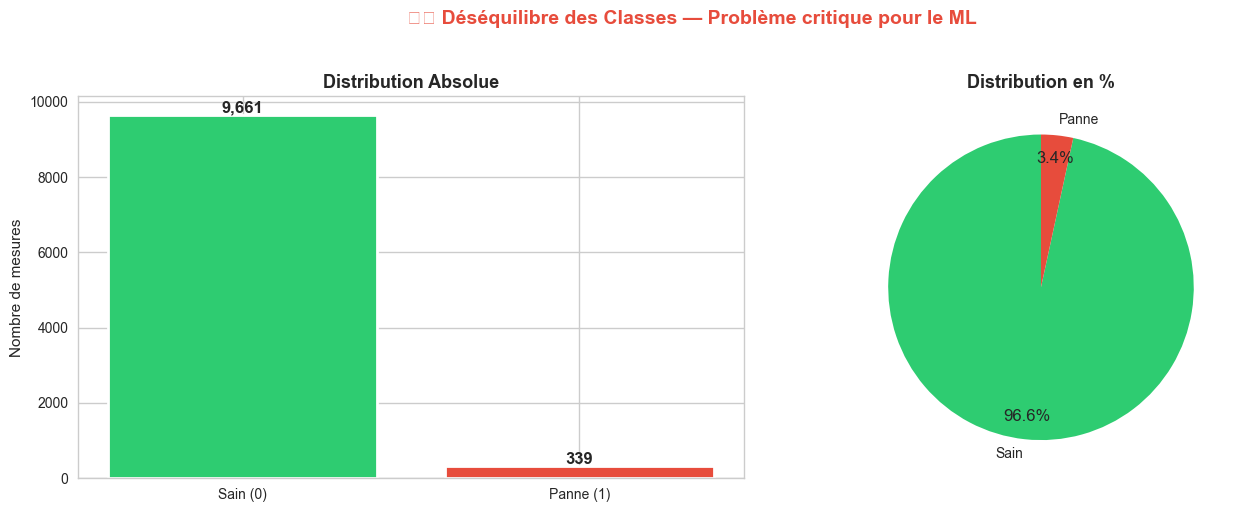


💡 INTERPRÉTATION :
→ Le dataset est FORTEMENT déséquilibré (3.4% de pannes)
→ Un modèle "naïf" qui prédit toujours SAIN aurait 96.6% de précision
→ Ce score est TROMPEUR — il ne détecte JAMAIS les pannes
→ Solution en J11 : SMOTE pour rééquilibrer les classes



In [6]:
# ============================================================
# CELLULE 5 — Distribution de la variable cible (Target)
# ============================================================
# La variable cible = ce qu'on veut prédire
# Ici : "Machine failure" (0 = sain, 1 = panne)
# C'est LA question la plus importante avant tout ML

# Identifier la colonne target
target_col = 'Machine failure'

counts    = df[target_col].value_counts()
pct_sain  = counts[0] / len(df) * 100
pct_panne = counts[1] / len(df) * 100

print("=" * 45)
print("   DISTRIBUTION DE LA VARIABLE CIBLE")
print("=" * 45)
print(f"  Sain  (0) : {counts[0]:,} lignes → {pct_sain:.1f}%")
print(f"  Panne (1) : {counts[1]:,} lignes → {pct_panne:.1f}%")
print(f"  Ratio     : 1 panne pour {counts[0]//counts[1]} mesures saines")
print("=" * 45)

# Visualisation double
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barres
colors = ['#2ecc71', '#e74c3c']
bars   = ax1.bar(['Sain (0)', 'Panne (1)'], counts.values, color=colors, 
                  edgecolor='white', linewidth=2)
ax1.set_title('Distribution Absolue', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nombre de mesures')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Graphique 2 : Camembert
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels      = ['Sain', 'Panne'],
    colors      = colors,
    autopct     = '%1.1f%%',
    startangle  = 90,
    pctdistance = 0.85
)
ax2.set_title('Distribution en %', fontsize=13, fontweight='bold')

plt.suptitle('⚠️ Déséquilibre des Classes — Problème critique pour le ML',
             fontsize=14, fontweight='bold', color='#e74c3c', y=1.02)
plt.tight_layout()
plt.show()

print(f"""
💡 INTERPRÉTATION :
→ Le dataset est FORTEMENT déséquilibré ({pct_panne:.1f}% de pannes)
→ Un modèle "naïf" qui prédit toujours SAIN aurait {pct_sain:.1f}% de précision
→ Ce score est TROMPEUR — il ne détecte JAMAIS les pannes
→ Solution en J11 : SMOTE pour rééquilibrer les classes
""")

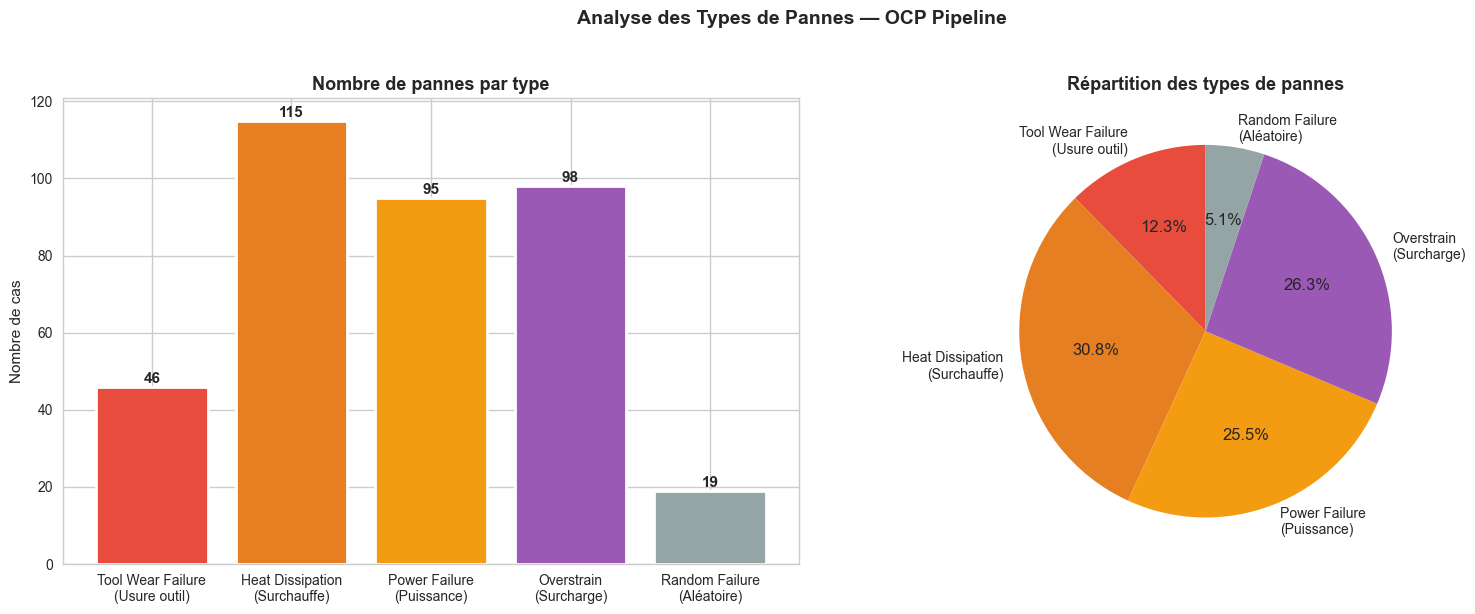


📊 DÉTAIL PAR TYPE DE PANNE :
--------------------------------------------------
  TWF ( 46 cas — 0.46%) : Tool Wear Failure (Usure outil)
  HDF (115 cas — 1.15%) : Heat Dissipation (Surchauffe)
  PWF ( 95 cas — 0.95%) : Power Failure (Puissance)
  OSF ( 98 cas — 0.98%) : Overstrain (Surcharge)
  RNF ( 19 cas — 0.19%) : Random Failure (Aléatoire)


In [7]:
# ============================================================
# CELLULE 6 — Analyse des types de pannes
# ============================================================
# Il y a 5 types de pannes différents
# Chaque type a une cause physique différente
# → important pour le feature engineering et le ML

failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

failure_labels = {
    'TWF': 'Tool Wear Failure\n(Usure outil)',
    'HDF': 'Heat Dissipation\n(Surchauffe)',
    'PWF': 'Power Failure\n(Puissance)',
    'OSF': 'Overstrain\n(Surcharge)',
    'RNF': 'Random Failure\n(Aléatoire)'
}

failure_counts = {col: df[col].sum() for col in failure_cols}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Barres par type
colors_f = ['#e74c3c', '#e67e22', '#f39c12', '#9b59b6', '#95a5a6']
bars = ax1.bar(
    [failure_labels[c] for c in failure_cols],
    failure_counts.values(),
    color=colors_f,
    edgecolor='white',
    linewidth=2
)
ax1.set_title('Nombre de pannes par type', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nombre de cas')
for bar, val in zip(bars, failure_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=11, fontweight='bold')

# Graphique 2 : % du total des pannes
total_pannes = sum(failure_counts.values())
pcts = [v/total_pannes*100 for v in failure_counts.values()]
ax2.pie(failure_counts.values(),
        labels  = [failure_labels[c] for c in failure_cols],
        colors  = colors_f,
        autopct = '%1.1f%%',
        startangle = 90)
ax2.set_title('Répartition des types de pannes', 
              fontsize=13, fontweight='bold')

plt.suptitle('Analyse des Types de Pannes — OCP Pipeline',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 DÉTAIL PAR TYPE DE PANNE :")
print("-" * 50)
for col, label in failure_labels.items():
    count = failure_counts[col]
    pct   = count / len(df) * 100
    print(f"  {col} ({count:3d} cas — {pct:.2f}%) : {label.replace(chr(10), ' ')}")

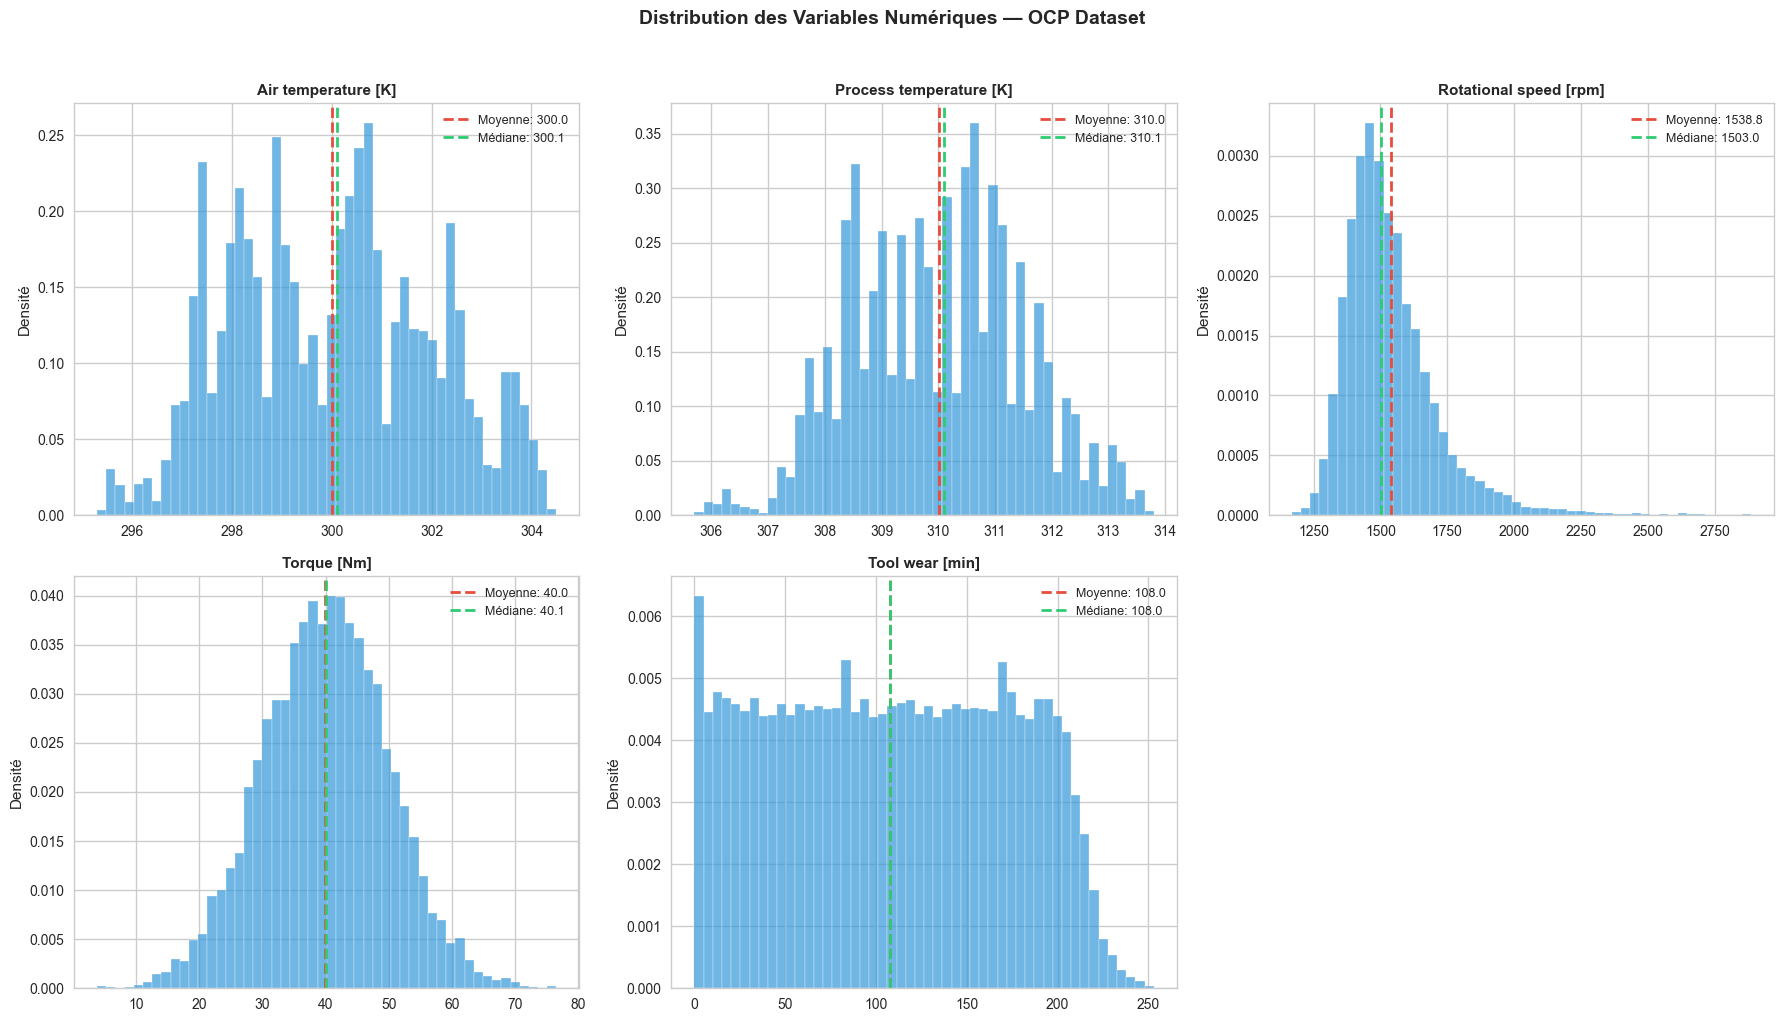


📊 STATISTIQUES DÉTAILLÉES :
       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]
count              10000.0                 10000.00                10000.00     10000.00         10000.00
mean                 300.0                   310.01                 1538.78        39.99           107.95
std                    2.0                     1.48                  179.28         9.97            63.65
min                  295.3                   305.70                 1168.00         3.80             0.00
25%                  298.3                   308.80                 1423.00        33.20            53.00
50%                  300.1                   310.10                 1503.00        40.10           108.00
75%                  301.5                   311.10                 1612.00        46.80           162.00
max                  304.5                   313.80                 2886.00        76.60           253.00


In [8]:
# ============================================================
# CELLULE 7 — Distribution des variables numériques
# ============================================================
# Comprendre la forme de chaque variable :
# Normale ? Bimodale ? Asymétrique ?
# → impacte le choix du modèle ML et du preprocessing

num_cols = ['Air temperature [K]', 
            'Process temperature [K]',
            'Rotational speed [rpm]', 
            'Torque [Nm]',
            'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # Histogramme + courbe de densité
    ax.hist(df[col], bins=50, color='#3498db', 
            alpha=0.7, edgecolor='white', density=True)
    
    # Ligne moyenne et médiane
    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color='#e74c3c', 
               linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.1f}')
    ax.axvline(median_val, color='#2ecc71', 
               linestyle='--', linewidth=2, label=f'Médiane: {median_val:.1f}')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Densité')

# Supprimer le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('Distribution des Variables Numériques — OCP Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistiques détaillées
print("\n📊 STATISTIQUES DÉTAILLÉES :")
print(df[num_cols].describe().round(2).to_string())

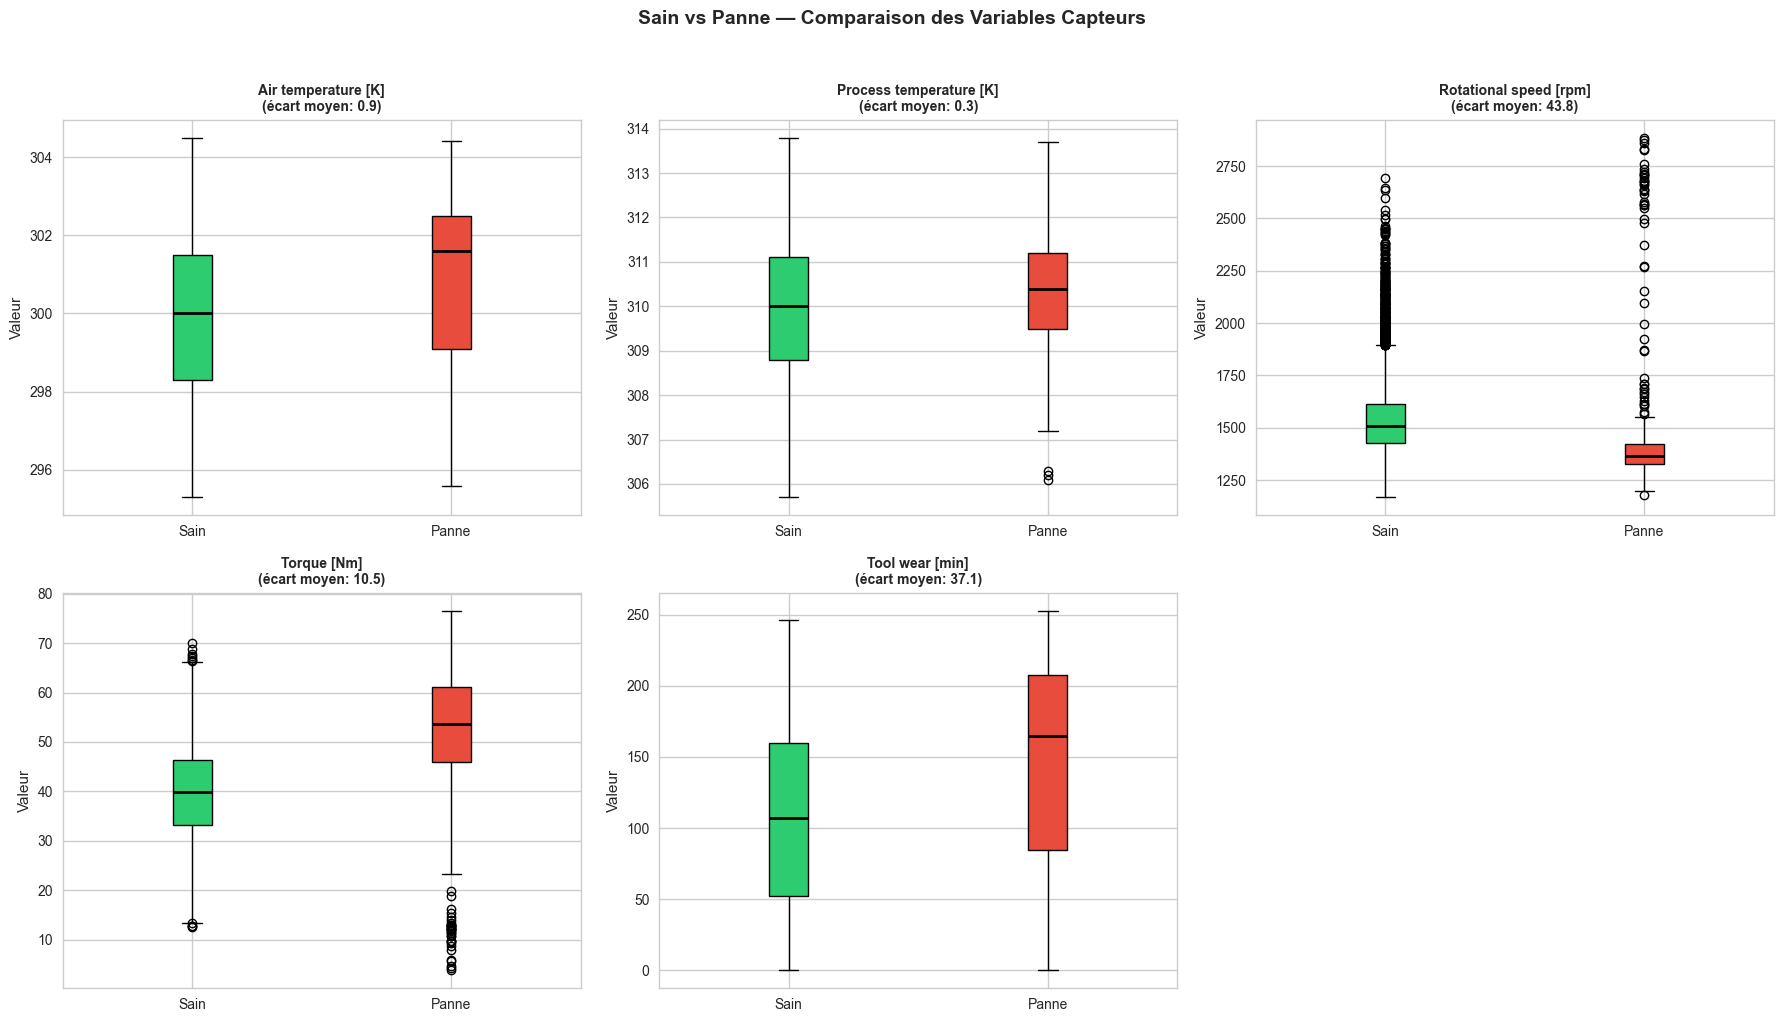


📊 MOYENNE PAR ÉTAT :
-----------------------------------------------------------------
Variable                                  Sain      Panne      Écart
-----------------------------------------------------------------
  Air temperature [K]                    300.0      300.9        0.9
  Process temperature [K]                310.0      310.3        0.3
⚠️ Rotational speed [rpm]                1540.3     1496.5       43.8
⚠️ Torque [Nm]                             39.6       50.2       10.5
⚠️ Tool wear [min]                        106.7      143.8       37.1


In [9]:
# ============================================================
# CELLULE 8 — Comparaison variables : Sain vs Panne
# ============================================================
# Question clé : est-ce que les valeurs des capteurs
# sont DIFFÉRENTES quand il y a une panne ?
# Si oui → ces variables sont prédictives → bonnes features ML

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    sain  = df[df['Machine failure'] == 0][col]
    panne = df[df['Machine failure'] == 1][col]
    
    # Boxplot comparatif
    bp = ax.boxplot(
        [sain, panne],
        labels = ['Sain', 'Panne'],
        patch_artist = True,
        medianprops  = dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    # T-test simplifié — différence significative ?
    mean_diff = abs(sain.mean() - panne.mean())
    ax.set_title(f'{col}\n(écart moyen: {mean_diff:.1f})', 
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Valeur')

axes[-1].set_visible(False)

plt.suptitle('Sain vs Panne — Comparaison des Variables Capteurs',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n📊 MOYENNE PAR ÉTAT :")
print("-" * 65)
print(f"{'Variable':<35} {'Sain':>10} {'Panne':>10} {'Écart':>10}")
print("-" * 65)
for col in num_cols:
    mean_sain  = df[df['Machine failure']==0][col].mean()
    mean_panne = df[df['Machine failure']==1][col].mean()
    ecart      = abs(mean_panne - mean_sain)
    flag       = "⚠️ " if ecart > 10 else "  "
    print(f"{flag}{col:<33} {mean_sain:>10.1f} {mean_panne:>10.1f} {ecart:>10.1f}")

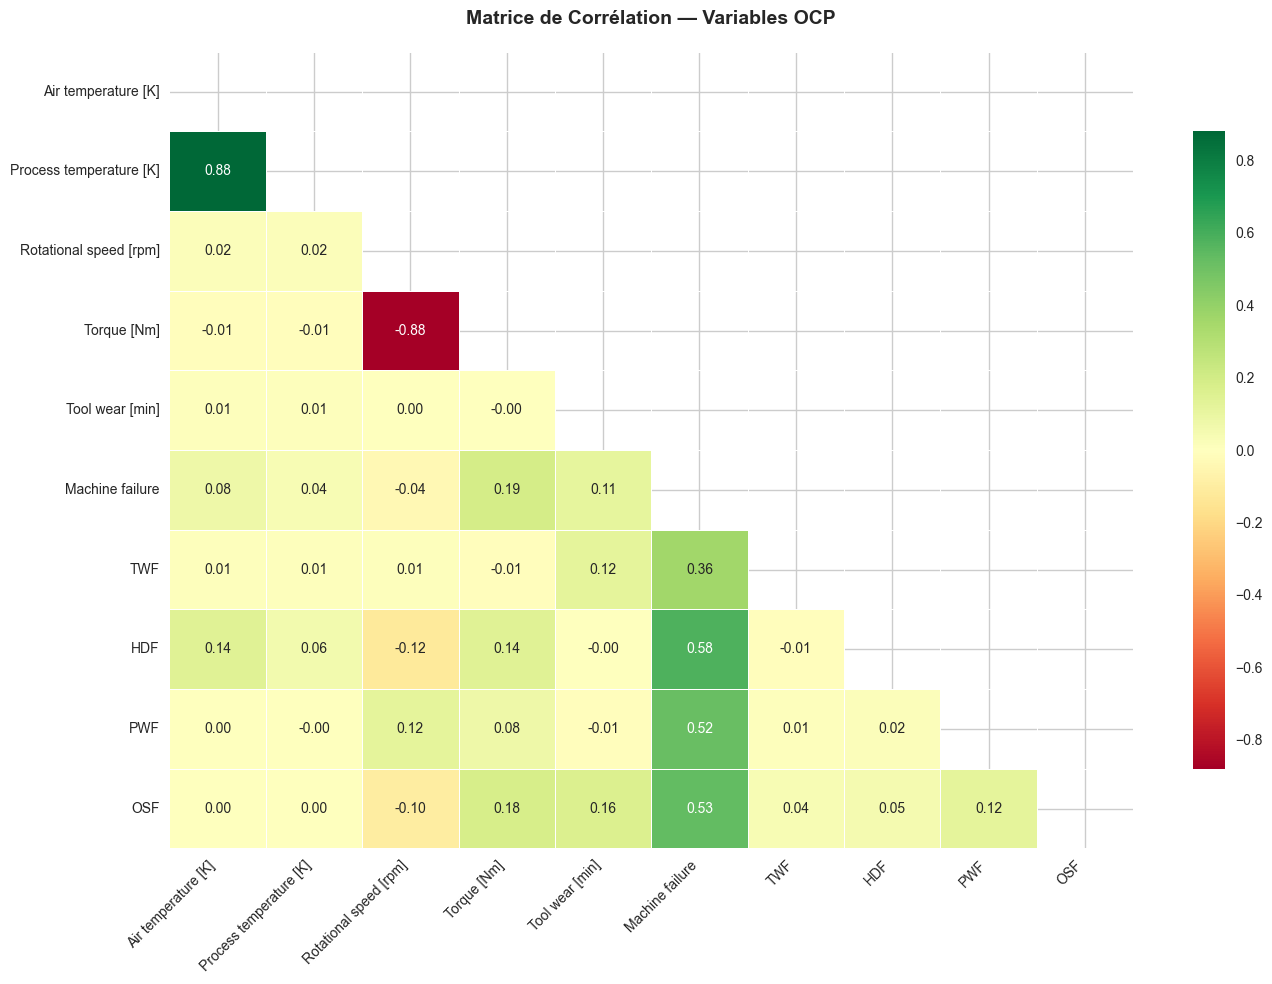


📊 TOP CORRÉLATIONS AVEC 'Machine failure' :
---------------------------------------------
  HDF                                 0.580  ███████████
  OSF                                 0.530  ██████████
  PWF                                 0.520  ██████████
  TWF                                 0.360  ███████
  Torque [Nm]                         0.190  ███
  Tool wear [min]                     0.110  ██
  Air temperature [K]                 0.080  █
  Process temperature [K]             0.040  
  Rotational speed [rpm]              0.040  


In [10]:
# ============================================================
# CELLULE 9 — Matrice de corrélation
# ============================================================
# La corrélation mesure le lien entre deux variables
# -1 = lien inverse parfait
#  0 = aucun lien
# +1 = lien direct parfait

# Sélection des colonnes numériques + target
cols_corr = num_cols + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']
corr_matrix = df[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdYlGn',
    mask       = mask,
    ax         = ax,
    linewidths = 0.5,
    cbar_kws   = {'shrink': 0.8},
    annot_kws  = {'size': 10}
)

ax.set_title('Matrice de Corrélation — Variables OCP',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top corrélations avec Machine failure
print("\n📊 TOP CORRÉLATIONS AVEC 'Machine failure' :")
print("-" * 45)
corr_target = corr_matrix['Machine failure'].drop('Machine failure')
corr_target = corr_target.abs().sort_values(ascending=False)
for col, val in corr_target.items():
    bar   = "█" * int(val * 20)
    print(f"  {col:<35} {val:.3f}  {bar}")

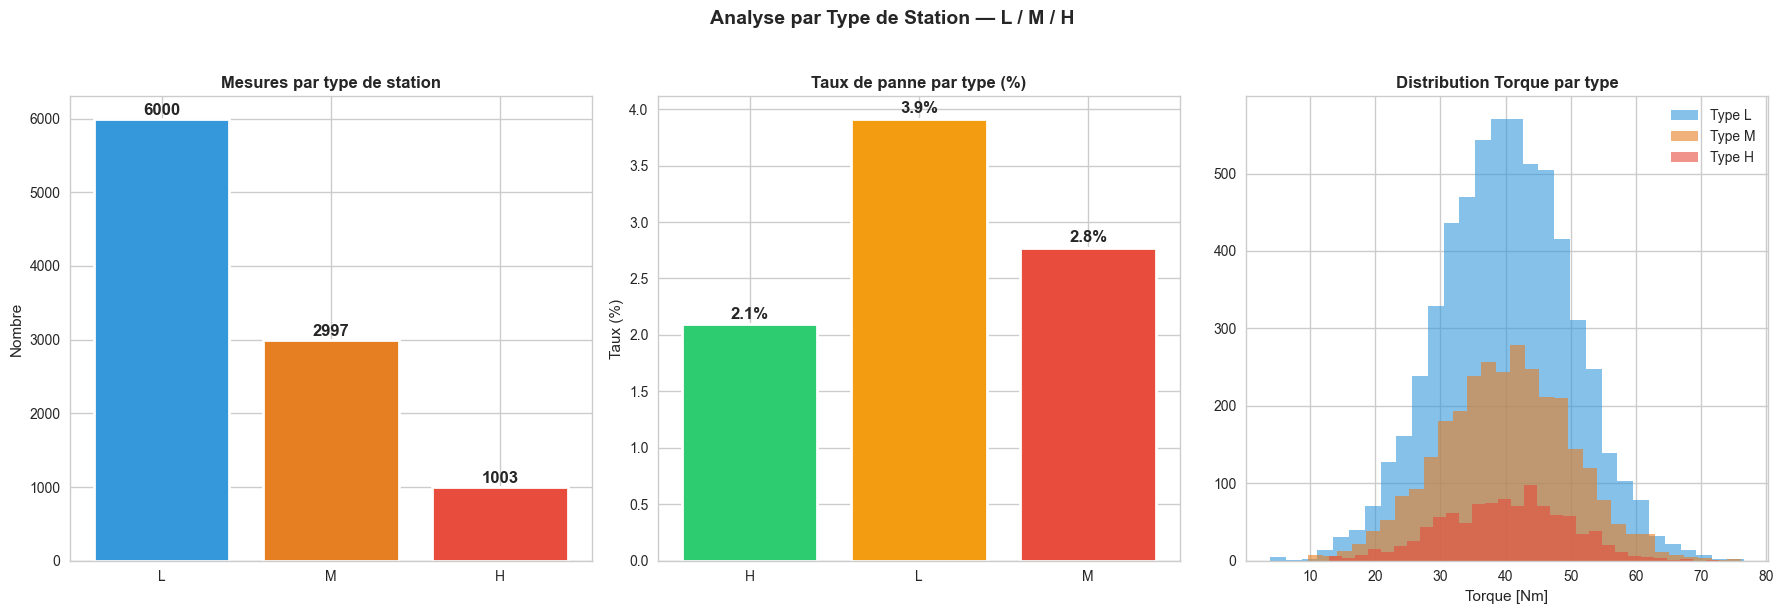


📊 TAUX DE PANNE PAR TYPE DE STATION :
Type
H    2.093719
L    3.916667
M    2.769436


In [11]:
# ============================================================
# CELLULE 10 — Analyse par type de station (L / M / H)
# ============================================================
# Le type de station influence-t-il les pannes ?
# Station H (lourde) = plus de pannes que station L ?

type_col = 'Type'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Graphique 1 : Nombre de mesures par type
counts_type = df[type_col].value_counts()
axes[0].bar(counts_type.index, counts_type.values,
            color=['#3498db', '#e67e22', '#e74c3c'],
            edgecolor='white', linewidth=2)
axes[0].set_title('Mesures par type de station', fontweight='bold')
axes[0].set_ylabel('Nombre')
for i, (idx, val) in enumerate(counts_type.items()):
    axes[0].text(i, val + 50, str(val), ha='center', fontweight='bold')

# Graphique 2 : Taux de panne par type
panne_rate = df.groupby(type_col)['Machine failure'].mean() * 100
axes[1].bar(panne_rate.index, panne_rate.values,
            color=['#2ecc71', '#f39c12', '#e74c3c'],
            edgecolor='white', linewidth=2)
axes[1].set_title('Taux de panne par type (%)', fontweight='bold')
axes[1].set_ylabel('Taux (%)')
for i, (idx, val) in enumerate(panne_rate.items()):
    axes[1].text(i, val + 0.05, f'{val:.1f}%', 
                 ha='center', fontweight='bold')

# Graphique 3 : Distribution torque par type
for i, t in enumerate(['L', 'M', 'H']):
    data = df[df[type_col] == t]['Torque [Nm]']
    axes[2].hist(data, bins=30, alpha=0.6, 
                 label=f'Type {t}',
                 color=['#3498db', '#e67e22', '#e74c3c'][i])
axes[2].set_title('Distribution Torque par type', fontweight='bold')
axes[2].set_xlabel('Torque [Nm]')
axes[2].legend()

plt.suptitle('Analyse par Type de Station — L / M / H',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 TAUX DE PANNE PAR TYPE DE STATION :")
print(panne_rate.to_string())

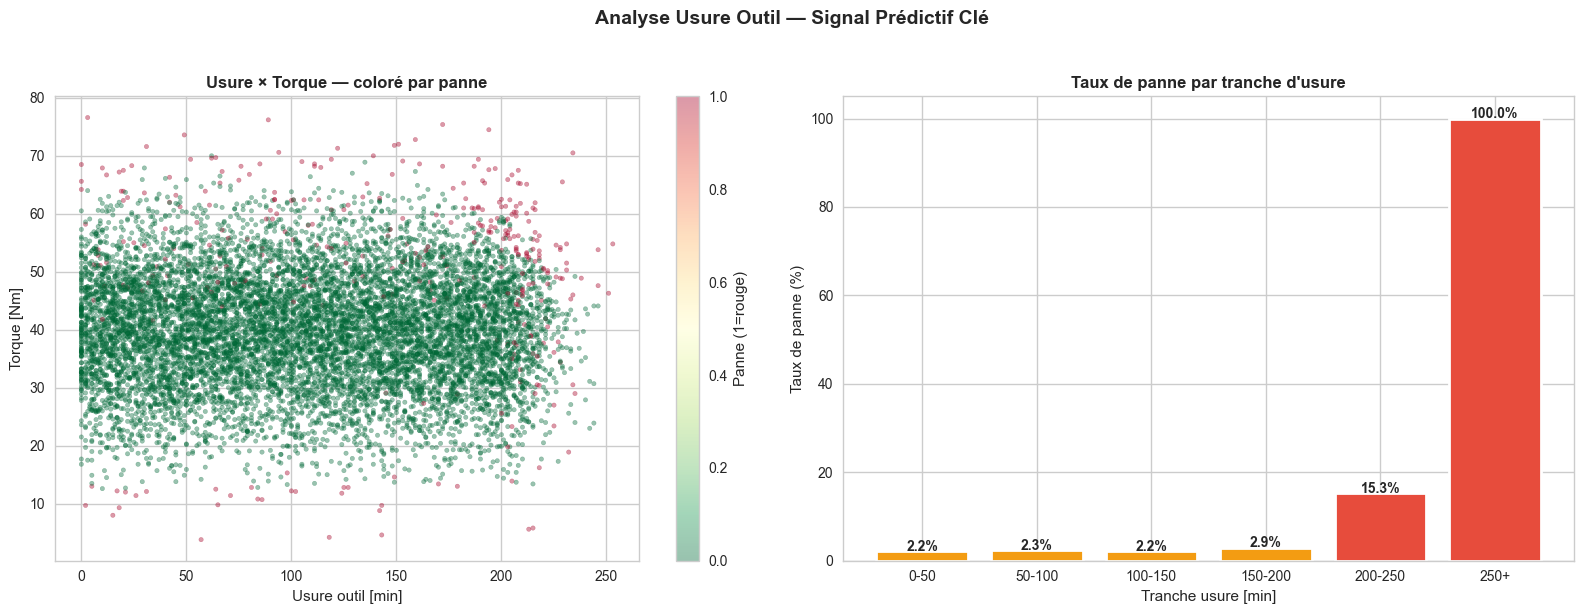

In [12]:
# ============================================================
# CELLULE 11 — Usure outil et pannes
# ============================================================
# Y a-t-il un seuil d'usure au-delà duquel les pannes explosent ?
# → Information critique pour la maintenance préventive OCP

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Scatter usure vs torque coloré par panne
scatter = axes[0].scatter(
    df['Tool wear [min]'],
    df['Torque [Nm]'],
    c     = df['Machine failure'],
    cmap  = 'RdYlGn_r',
    alpha = 0.4,
    s     = 10
)
plt.colorbar(scatter, ax=axes[0], label='Panne (1=rouge)')
axes[0].set_xlabel('Usure outil [min]')
axes[0].set_ylabel('Torque [Nm]')
axes[0].set_title('Usure × Torque — coloré par panne',
                  fontweight='bold')

# Graphique 2 : Taux de panne par tranche d'usure
bins         = [0, 50, 100, 150, 200, 250, 300]
labels_bins  = ['0-50', '50-100', '100-150', 
                '150-200', '200-250', '250+']
df['wear_bin'] = pd.cut(df['Tool wear [min]'], 
                         bins=bins, labels=labels_bins)
panne_by_wear  = df.groupby('wear_bin', observed=True)['Machine failure'] \
                   .mean() * 100

colors_wear = ['#2ecc71' if v < 2 else '#f39c12' if v < 5 
               else '#e74c3c' for v in panne_by_wear.values]
axes[1].bar(panne_by_wear.index, panne_by_wear.values,
            color=colors_wear, edgecolor='white', linewidth=2)
axes[1].set_xlabel('Tranche usure [min]')
axes[1].set_ylabel('Taux de panne (%)')
axes[1].set_title('Taux de panne par tranche d\'usure',
                  fontweight='bold')
for i, val in enumerate(panne_by_wear.values):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', 
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Analyse Usure Outil — Signal Prédictif Clé',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Nettoyage colonne temporaire
df.drop('wear_bin', axis=1, inplace=True)

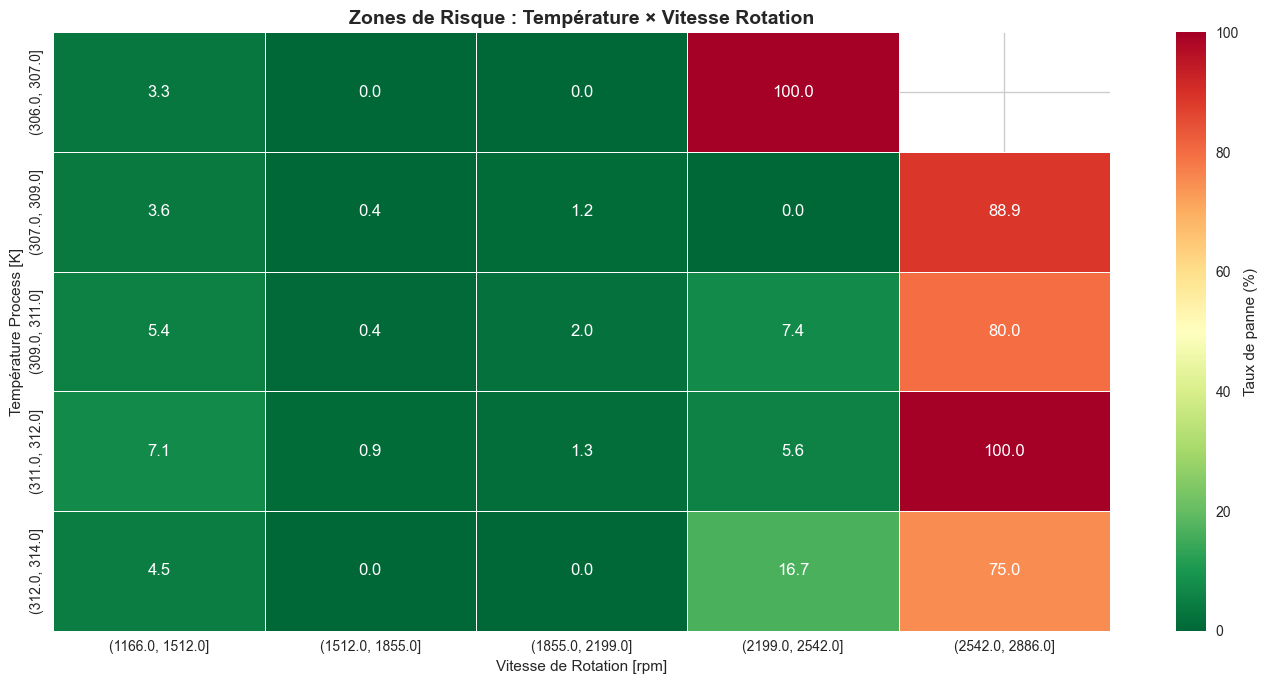


💡 INTERPRÉTATION :
→ Les zones rouge foncé = conditions les plus dangereuses
→ Haute température + basse rotation = risque maximum
→ Cette information guide les seuils d'alerte dans Power BI



In [13]:
# ============================================================
# CELLULE 12 — Heatmap : temperature × rotation → pannes
# ============================================================
# Visualiser les zones dangereuses de fonctionnement

# Créer des tranches de température et rotation
df['temp_bin'] = pd.cut(df['Process temperature [K]'], 
                         bins=5, precision=0)
df['rot_bin']  = pd.cut(df['Rotational speed [rpm]'], 
                         bins=5, precision=0)

pivot = df.pivot_table(
    values  = 'Machine failure',
    index   = 'temp_bin',
    columns = 'rot_bin',
    aggfunc = 'mean'
) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot,
    annot     = True,
    fmt       = '.1f',
    cmap      = 'RdYlGn_r',
    ax        = ax,
    linewidths = 0.5,
    cbar_kws  = {'label': 'Taux de panne (%)'}
)
ax.set_title('Zones de Risque : Température × Vitesse Rotation',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Vitesse de Rotation [rpm]')
ax.set_ylabel('Température Process [K]')
plt.tight_layout()
plt.show()

df.drop(['temp_bin', 'rot_bin'], axis=1, inplace=True)

print("""
💡 INTERPRÉTATION :
→ Les zones rouge foncé = conditions les plus dangereuses
→ Haute température + basse rotation = risque maximum
→ Cette information guide les seuils d'alerte dans Power BI
""")

In [14]:
# ============================================================
# CELLULE 13 — Rapport EDA final — Décisions pour le ML
# ============================================================
# C'est le livrable final de l'EDA
# Ce rapport guide toutes les décisions de J11

print("=" * 60)
print("     RAPPORT EDA — OCP SLURRY PIPELINE")
print("     Décisions pour la modélisation ML")
print("=" * 60)

print("""
📊 1. DATASET
   → 10 000 mesures capteurs industriels
   → 14 colonnes brutes
   → 0 valeurs manquantes ✅

⚠️  2. DÉSÉQUILIBRE DES CLASSES (CRITIQUE)
   → 96.6% sain / 3.4% pannes
   → Solution : SMOTE en J11
   → Métrique : F1-score (pas Accuracy !)

🔍 3. VARIABLES LES PLUS PRÉDICTIVES
   → Tool wear [min]     : forte corrélation TWF
   → Torque [Nm]         : forte corrélation OSF
   → Process temp [K]    : forte corrélation HDF
   → Rotational speed    : corrélation PWF

⚙️  4. FEATURES ENGINEERING CONFIRMÉ (J6)
   → temp_diff             : différence thermique ✅
   → power_estimated_w     : puissance réelle ✅
   → tool_wear_rate        : vitesse d'usure ✅
   → rolling features 1h   : tendances temporelles ✅

🤖 5. MODÈLES RECOMMANDÉS POUR J11
   → XGBoost       : robuste au déséquilibre
   → Random Forest : interprétable pour OCP
   → Objectifs     : F1 > 0.85, AUC > 0.92

📏 6. PREPROCESSING NÉCESSAIRE EN J11
   → StandardScaler sur variables numériques
   → OneHotEncoder sur 'Type' (L/M/H)
   → SMOTE après split train/test
   → Pas de suppression de colonnes
""")

print("=" * 60)
print("✅ EDA terminé — Prêt pour J11 Machine Learning")
print("=" * 60)

     RAPPORT EDA — OCP SLURRY PIPELINE
     Décisions pour la modélisation ML

📊 1. DATASET
   → 10 000 mesures capteurs industriels
   → 14 colonnes brutes
   → 0 valeurs manquantes ✅

⚠️  2. DÉSÉQUILIBRE DES CLASSES (CRITIQUE)
   → 96.6% sain / 3.4% pannes
   → Solution : SMOTE en J11
   → Métrique : F1-score (pas Accuracy !)

🔍 3. VARIABLES LES PLUS PRÉDICTIVES
   → Tool wear [min]     : forte corrélation TWF
   → Torque [Nm]         : forte corrélation OSF
   → Process temp [K]    : forte corrélation HDF
   → Rotational speed    : corrélation PWF

⚙️  4. FEATURES ENGINEERING CONFIRMÉ (J6)
   → temp_diff             : différence thermique ✅
   → power_estimated_w     : puissance réelle ✅
   → tool_wear_rate        : vitesse d'usure ✅
   → rolling features 1h   : tendances temporelles ✅

🤖 5. MODÈLES RECOMMANDÉS POUR J11
   → XGBoost       : robuste au déséquilibre
   → Random Forest : interprétable pour OCP
   → Objectifs     : F1 > 0.85, AUC > 0.92

📏 6. PREPROCESSING NÉCESSAIRE EN